<a href="https://colab.research.google.com/github/srikavya26/Image-classification-challenge/blob/main/repvgg_a2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:


# Download CIFAR-10.1 v6 dataset
data_url = "https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_data.npy"
label_url = "https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_labels.npy"
urllib.request.urlretrieve(data_url, "cifar10.1_v6_data.npy")
urllib.request.urlretrieve(label_url, "cifar10.1_v6_labels.npy")

# Load data
data = np.load("cifar10.1_v6_data.npy")  # shape: (2000, 32, 32, 3)
labels = np.load("cifar10.1_v6_labels.npy")  # shape: (2000,)
print(f"Data min: {data.min()}, Data max: {data.max()}")

# Step 1: Dataset Structure
print("\n=== Dataset Structure ===")
print(f"Data Shape: {data.shape}, Dtype: {data.dtype}")
print(f"Labels Shape: {labels.shape}, Dtype: {labels.dtype}")
print(f"Number of Samples: {data.shape[0]}")
print(f"Image Dimensions: {data.shape[1]}x{data.shape[2]} pixels, {data.shape[3]} channels (RGB)")
print(f"Label Range: {labels.min()} to {labels.max()}")

# Step 2: Class Distribution
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_counts = np.bincount(labels)
print("\n=== Class Distribution ===")
for i, count in enumerate(class_counts):
    print(f"{class_names[i]} (Class {i}): {count} samples ({count/len(labels)*100:.1f}%)")




Data min: 0, Data max: 255

=== Dataset Structure ===
Data Shape: (2000, 32, 32, 3), Dtype: uint8
Labels Shape: (2000,), Dtype: int32
Number of Samples: 2000
Image Dimensions: 32x32 pixels, 3 channels (RGB)
Label Range: 0 to 9

=== Class Distribution ===
airplane (Class 0): 200 samples (10.0%)
automobile (Class 1): 200 samples (10.0%)
bird (Class 2): 200 samples (10.0%)
cat (Class 3): 200 samples (10.0%)
deer (Class 4): 200 samples (10.0%)
dog (Class 5): 200 samples (10.0%)
frog (Class 6): 200 samples (10.0%)
horse (Class 7): 200 samples (10.0%)
ship (Class 8): 200 samples (10.0%)
truck (Class 9): 200 samples (10.0%)


In [ ]:
# Step 3: Characteristics
print("\n=== Dataset Characteristics ===")
print("Dataset: CIFAR-10.1 v6, a new test set for CIFAR-10 with 2000 images.")
print("Image Properties: 32x32 pixels, RGB, low-resolution, centered objects.")
print("Classes: 10, balanced, covering vehicles (airplane, automobile, ship, truck) and animals (bird, cat, deer, dog, frog, horse).")
print("Challenges: Low resolution, visual similarity (e.g., cat/dog, airplane/ship), diverse lighting/backgrounds.")


=== Dataset Characteristics ===
Dataset: CIFAR-10.1 v6, a new test set for CIFAR-10 with 2000 images.
Image Properties: 32x32 pixels, RGB, low-resolution, centered objects.
Classes: 10, balanced, covering vehicles (airplane, automobile, ship, truck) and animals (bird, cat, deer, dog, frog, horse).
Challenges: Low resolution, visual similarity (e.g., cat/dog, airplane/ship), diverse lighting/backgrounds.


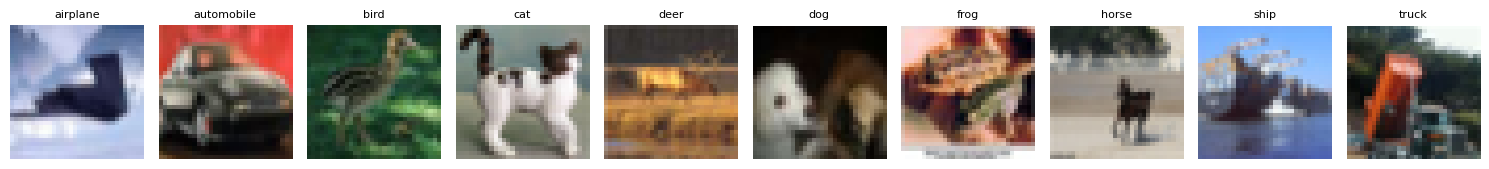

In [ ]:
# Step 4: Visualizations
# Visualization 1: Sample Images (1 per class)
plt.figure(figsize=(15, 2))
for i in range(10):
    idx = np.where(labels == i)[0][0]
    plt.subplot(1, 10, i+1)
    plt.imshow(data[idx].astype(np.uint8))
    plt.title(class_names[i], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

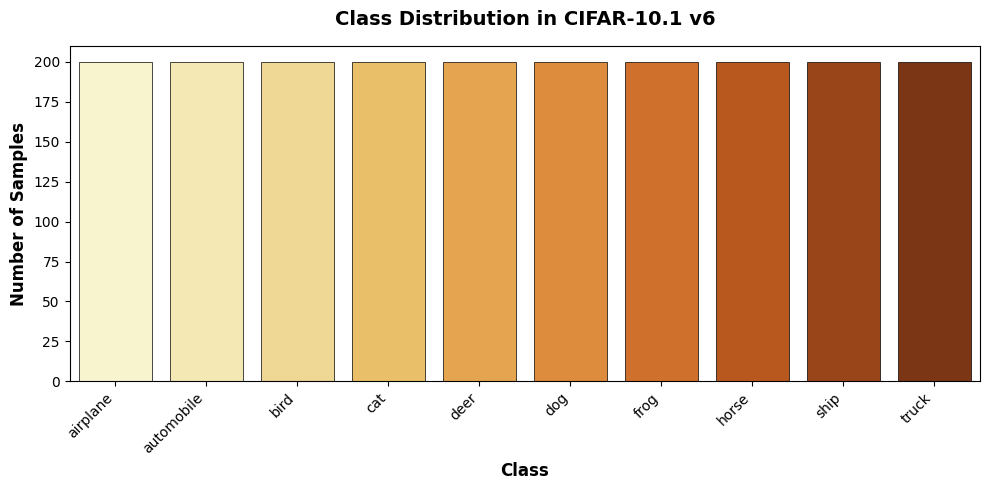

In [ ]:
# Visualization 2: Class Distribution Bar Chart

plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=class_counts, hue=class_names, palette='YlOrBr', edgecolor='black', linewidth=0.5, legend=False)
plt.xlabel('Class', fontsize=12, weight='bold')
plt.ylabel('Number of Samples', fontsize=12, weight='bold')
plt.title('Class Distribution in CIFAR-10.1 v6', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution_mako.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Define class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Define Albumentations transforms (following 7-step approach)
train_transform = A.Compose([
    # Step 1: Cropping
    A.PadIfNeeded(min_height=40, min_width=40, p=1.0),
    A.RandomCrop(height=32, width=32, p=1.0),
    # Step 2: Geometric Invariances
    A.HorizontalFlip(p=0.5),
    # Step 3: Dropout
    A.CoarseDropout(
        num_holes_range=(1, 2),
        hole_height_range=(0.1, 0.2),
        hole_width_range=(0.1, 0.2),
        fill=0,
        p=0.5
    ),
    # Step 4: Color Reduction
    A.ToGray(p=0.1),
    # Step 5: Affine Transformations
    A.Affine(scale=(0.8, 1.2), rotate=(-15, 15), p=0.5),
    # Step 6: Color Augmentations
    A.ColorJitter(brightness=0.1, contrast=0.3, saturation=0.1, hue=0.1, p=0.4),
    # Step 7: Normalization
    A.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.243, 0.261), p=1.0),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.243, 0.261), p=1.0),
    ToTensorV2(),
])

# Function to visualize original and augmented images
def visualize_augmentations(data, labels, class_names, transform, class_labels=None, num_images=10):

    # Filter by class_labels if specified
    if class_labels is not None:
        if isinstance(class_labels, int):
            class_labels = [class_labels]
        mask = np.isin(labels, class_labels)
        selected_data = data[mask]
        selected_labels = labels[mask]
        if len(selected_data) == 0:
            print(f"No images found for class labels: {class_labels}")
            return
    else:
        selected_data = data
        selected_labels = labels

    # Randomly select up to num_images
    indices = np.random.choice(len(selected_data), min(num_images, len(selected_data)), replace=False)
    selected_images = selected_data[indices]
    selected_labels = selected_labels[indices]

    # Set up plot
    plt.figure(figsize=(4 * len(indices), 4))

    for i, (img, label) in enumerate(zip(selected_images, selected_labels)):
        # Original image
        plt.subplot(2, len(indices), i + 1)
        plt.imshow(img.astype(np.uint8))
        plt.title(f"{class_names[label]} (Original)", fontsize=10)
        plt.axis('off')

        # Augmented image
        aug_img = transform(image=img.astype(np.uint8))['image']
        aug_img = aug_img.permute(1, 2, 0).numpy()  # (C, H, W) to (H, W, C)
        aug_img = aug_img * np.array([0.247, 0.243, 0.261]) + np.array([0.4914, 0.4822, 0.4465])
        aug_img = np.clip(aug_img, 0, 1)
        plt.subplot(2, len(indices), i + 1 + len(indices))
        plt.imshow(aug_img)
        plt.title(f"{class_names[label]} (Augmented)", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()




=== Visualizing Augmentations for All Classes ===


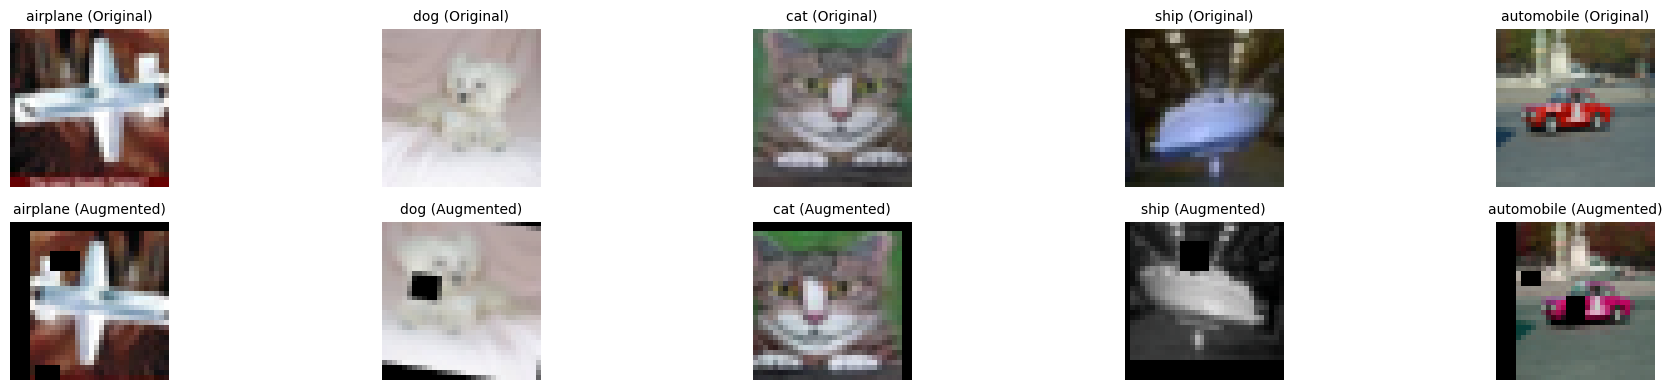


=== Visualizing Augmentations for Class 0 (Airplane) ===


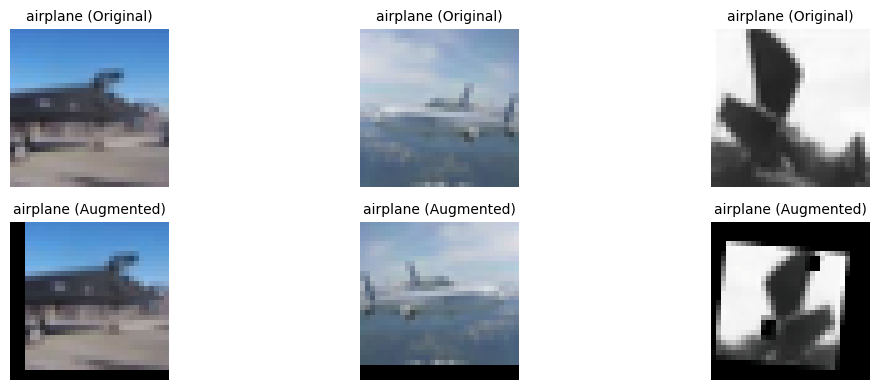


=== Visualizing Augmentations for Classes 0 (Airplane) and 3 (Cat) ===


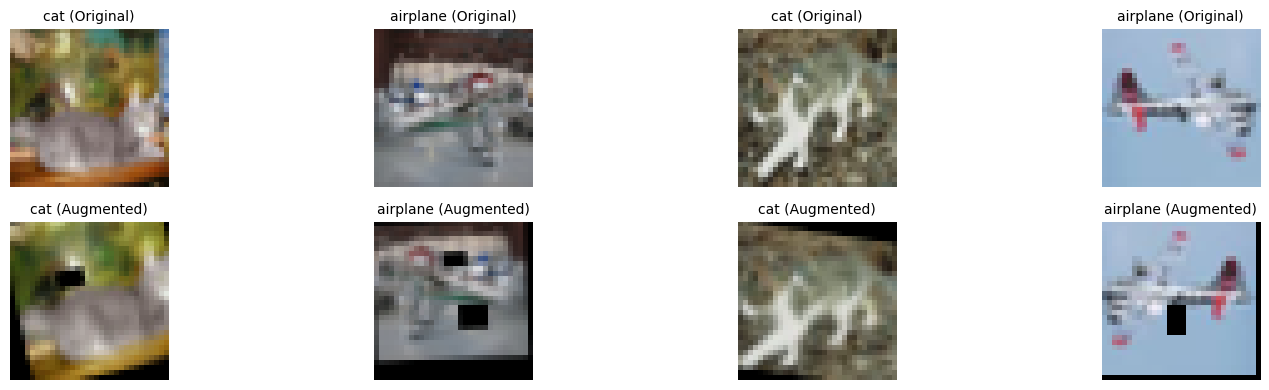

In [ ]:
# Example visualizations
print("\n=== Visualizing Augmentations for All Classes ===")
visualize_augmentations(data, labels, class_names, train_transform, class_labels=None, num_images=5)

print("\n=== Visualizing Augmentations for Class 0 (Airplane) ===")
visualize_augmentations(data, labels, class_names, train_transform, class_labels=0, num_images=3)

print("\n=== Visualizing Augmentations for Classes 0 (Airplane) and 3 (Cat) ===")
visualize_augmentations(data, labels, class_names, train_transform, class_labels=[0, 3], num_images=4)

In [ ]:
# Custom dataset for CIFAR-10.1
class CIFAR10_1_Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].numpy().astype(np.uint8)
        label = self.labels[idx]
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        return img, label

In [ ]:
# MixUp function
def mixup_data(x, y, alpha=0.2, device='cuda'):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

In [ ]:

# Test-Time Augmentation (TTA) function
def apply_tta(model, images, device):
    model.eval()
    with torch.no_grad():
        outputs = model(images)
        flipped_h = torch.flip(images, dims=[3])  # Horizontal flip
        outputs += model(flipped_h)
        outputs /= 2
    return outputs

## Model's Archietecture

In [ ]:
import torch
model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_repvgg_a2", pretrained=True)

/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/repvgg/cifar10_repvgg_a2-09488915.pt" to /root/.cache/torch/hub/checkpoints/cifar10_repvgg_a2-09488915.pt
100%|██████████| 103M/103M [00:01<00:00, 84.7MB/s

In [ ]:
import torch
state_dict = torch.load("path_to_repvgg_a2.pt")
for key, value in state_dict.items():
    print(key, value.shape)

In [ ]:
print(model)

RepVGG(
  (stage0): RepVGGBlock(
    (nonlinearity): ReLU()
    (rbr_dense): Sequential(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (rbr_1x1): Sequential(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stage1): Sequential(
    (0): RepVGGBlock(
      (nonlinearity): ReLU()
      (rbr_dense): Sequential(
        (conv): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (rbr_1x1): Sequential(
        (conv): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
 

In [ ]:

state_dict = torch.load("/content/cifar10_repvgg_a2-09488915.pt")
for key, value in state_dict.items():
    print(key, value.shape)

stage0.rbr_dense.conv.weight torch.Size([64, 3, 3, 3])
stage0.rbr_dense.bn.weight torch.Size([64])
stage0.rbr_dense.bn.bias torch.Size([64])
stage0.rbr_dense.bn.running_mean torch.Size([64])
stage0.rbr_dense.bn.running_var torch.Size([64])
stage0.rbr_dense.bn.num_batches_tracked torch.Size([])
stage0.rbr_1x1.conv.weight torch.Size([64, 3, 1, 1])
stage0.rbr_1x1.bn.weight torch.Size([64])
stage0.rbr_1x1.bn.bias torch.Size([64])
stage0.rbr_1x1.bn.running_mean torch.Size([64])
stage0.rbr_1x1.bn.running_var torch.Size([64])
stage0.rbr_1x1.bn.num_batches_tracked torch.Size([])
stage1.0.rbr_dense.conv.weight torch.Size([96, 64, 3, 3])
stage1.0.rbr_dense.bn.weight torch.Size([96])
stage1.0.rbr_dense.bn.bias torch.Size([96])
stage1.0.rbr_dense.bn.running_mean torch.Size([96])
stage1.0.rbr_dense.bn.running_var torch.Size([96])
stage1.0.rbr_dense.bn.num_batches_tracked torch.Size([])
stage1.0.rbr_1x1.conv.weight torch.Size([96, 64, 1, 1])
stage1.0.rbr_1x1.bn.weight torch.Size([96])
stage1.0.rbr_1

Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/repvgg/cifar10_repvgg_a2-09488915.pt" to /root/.cache/torch/hub/checkpoints/cifar10_repvgg_a2-09488915.pt
100%|██████████| 103M/103M [00:02<00:00, 40.0MB/s]


Using device: cuda

=== Training Fold 1/5 ===
Fold 1 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 1, Epoch 1, Batch 50/50, Batch Loss: 1.3177
Fold 1, Epoch 1, Average Loss: 1.7153, Training Accuracy: 0.6344
Fold 1, Epoch 1, Validation Loss: 1.0326, Validation Accuracy (TTA): 0.8675
Fold 1, Epoch 2, Batch 50/50, Batch Loss: 1.1103
Fold 1, Epoch 2, Average Loss: 1.2519, Training Accuracy: 0.7013
Fold 1, Epoch 2, Validation Loss: 0.9277, Validation Accuracy (TTA): 0.8825
Fold 1, Epoch 3, Batch 50/50, Batch Loss: 1.0818
Fold 1, Epoch 3, Average Loss: 1.1325, Training Accuracy: 0.7700
Fold 1, Epoch 3, Validation Loss: 0.8818, Validation Accuracy (TTA): 0.8850
Fold 1, Epoch 4, Batch 50/50, Batch Loss: 1.1118
Fol

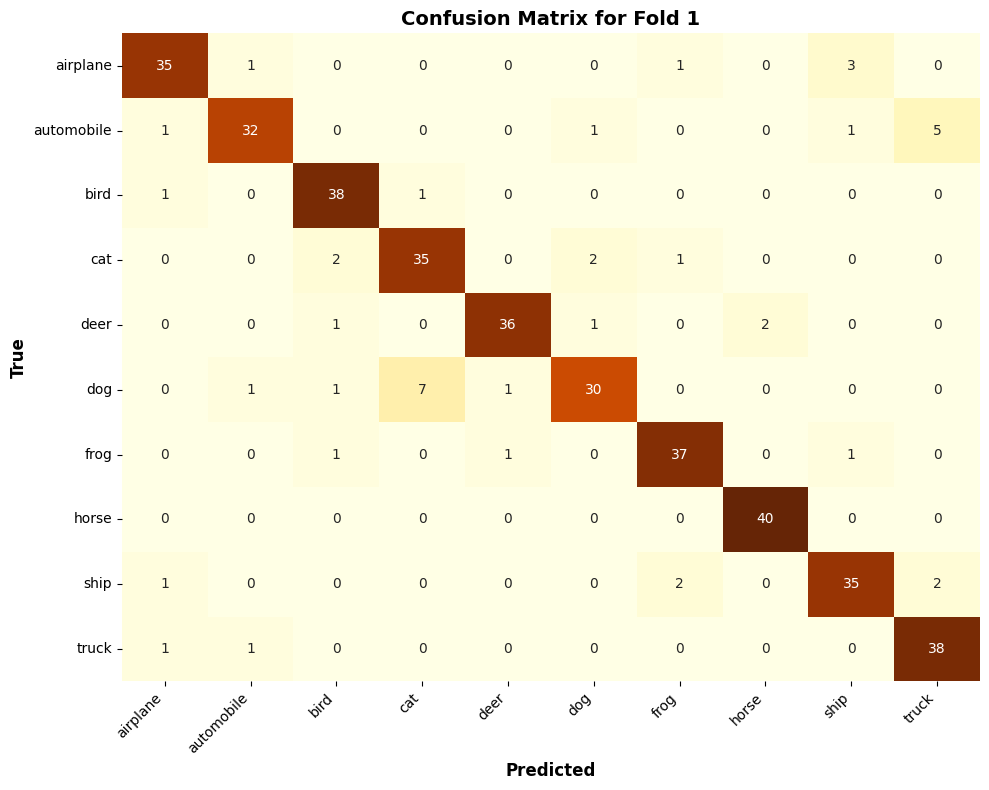


=== Training Fold 2/5 ===
Fold 2 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 2, Epoch 1, Batch 50/50, Batch Loss: 0.7809
Fold 2, Epoch 1, Average Loss: 0.9220, Training Accuracy: 0.7731
Fold 2, Epoch 1, Validation Loss: 0.5719, Validation Accuracy (TTA): 0.9925
Fold 2, Epoch 2, Batch 50/50, Batch Loss: 1.6061
Fold 2, Epoch 2, Average Loss: 0.8338, Training Accuracy: 0.8769
Fold 2, Epoch 2, Validation Loss: 0.5807, Validation Accuracy (TTA): 0.9875
Fold 2, Epoch 3, Batch 50/50, Batch Loss: 0.6264
Fold 2, Epoch 3, Average Loss: 0.8605, Training Accuracy: 0.7875
Fold 2, Epoch 3, Validation Loss: 0.5716, Validation Accuracy (TTA): 0.9900
Fold 2, Epoch 4, Batch 50/50, Batch Loss: 0.7382
Fold 2, Epoch 4, Avera

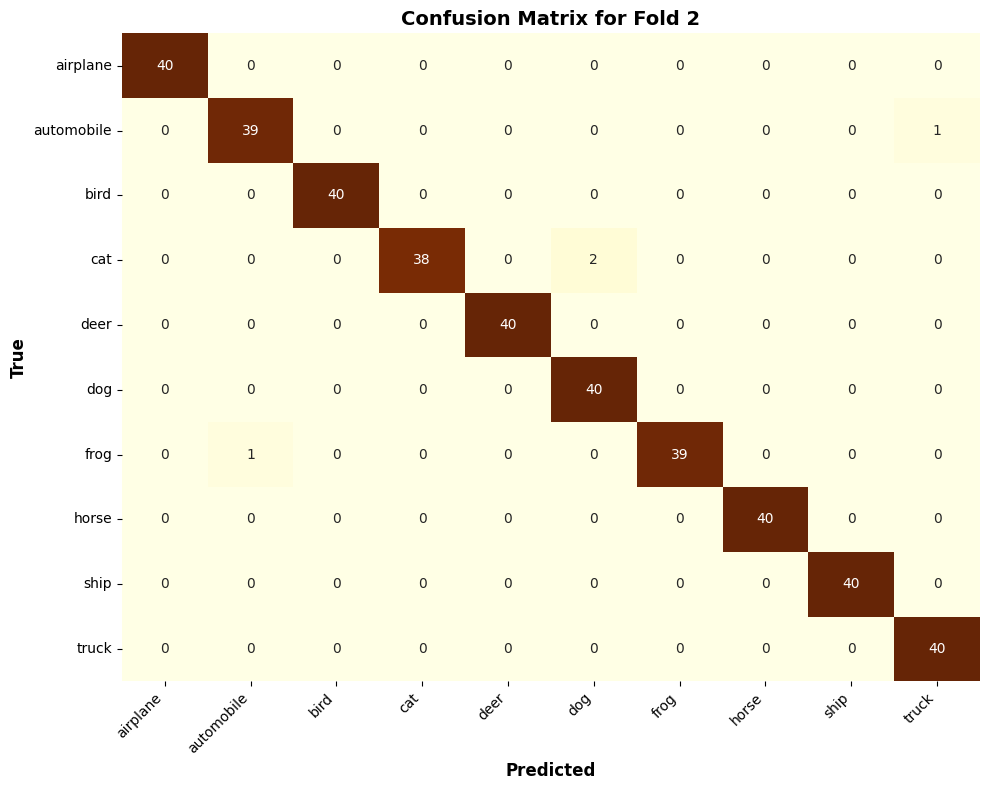


=== Training Fold 3/5 ===
Fold 3 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 3, Epoch 1, Batch 50/50, Batch Loss: 0.6472
Fold 3, Epoch 1, Average Loss: 0.7879, Training Accuracy: 0.8313
Fold 3, Epoch 1, Validation Loss: 0.5212, Validation Accuracy (TTA): 0.9975
Fold 3, Epoch 2, Batch 50/50, Batch Loss: 0.5575
Fold 3, Epoch 2, Average Loss: 0.7422, Training Accuracy: 0.7881
Fold 3, Epoch 2, Validation Loss: 0.5277, Validation Accuracy (TTA): 0.9975
Fold 3, Epoch 3, Batch 50/50, Batch Loss: 0.6762
Fold 3, Epoch 3, Average Loss: 0.6923, Training Accuracy: 0.8369
Fold 3, Epoch 3, Validation Loss: 0.5335, Validation Accuracy (TTA): 0.9950
Fold 3, Epoch 4, Batch 50/50, Batch Loss: 0.5876
Fold 3, Epoch 4, Avera

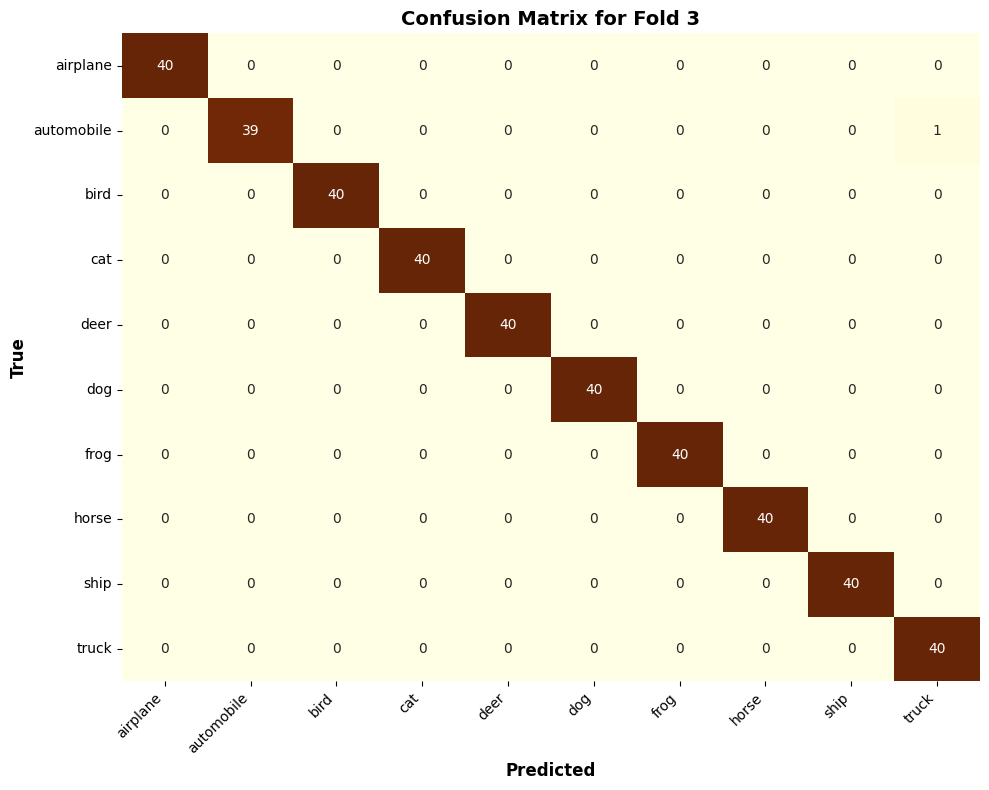


=== Training Fold 4/5 ===
Fold 4 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 4, Epoch 1, Batch 50/50, Batch Loss: 0.8174
Fold 4, Epoch 1, Average Loss: 0.7985, Training Accuracy: 0.8875
Fold 4, Epoch 1, Validation Loss: 0.5235, Validation Accuracy (TTA): 0.9975
Fold 4, Epoch 2, Batch 50/50, Batch Loss: 0.8312
Fold 4, Epoch 2, Average Loss: 0.7503, Training Accuracy: 0.8581
Fold 4, Epoch 2, Validation Loss: 0.5225, Validation Accuracy (TTA): 0.9975
Fold 4, Epoch 3, Batch 50/50, Batch Loss: 0.6309
Fold 4, Epoch 3, Average Loss: 0.7179, Training Accuracy: 0.8662
Fold 4, Epoch 3, Validation Loss: 0.5196, Validation Accuracy (TTA): 1.0000
Fold 4, Epoch 4, Batch 50/50, Batch Loss: 0.7073
Fold 4, Epoch 4, Avera

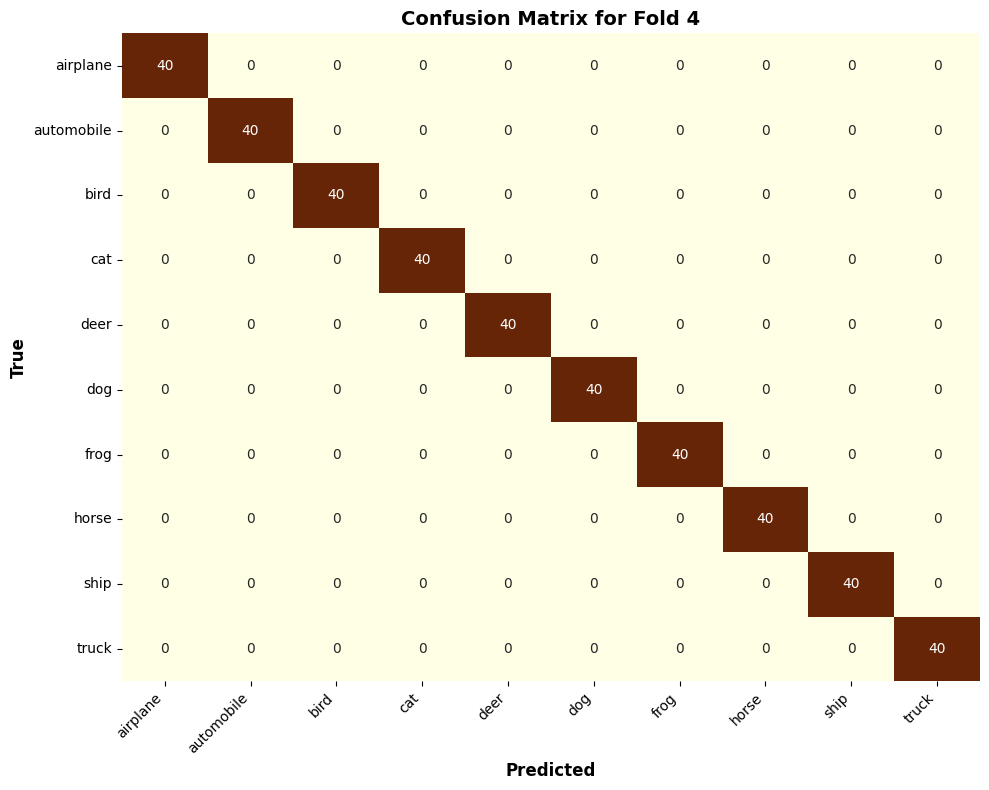


=== Training Fold 5/5 ===
Fold 5 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 5, Epoch 1, Batch 50/50, Batch Loss: 1.9558
Fold 5, Epoch 1, Average Loss: 0.7730, Training Accuracy: 0.8600
Fold 5, Epoch 1, Validation Loss: 0.5314, Validation Accuracy (TTA): 1.0000
Fold 5, Epoch 2, Batch 50/50, Batch Loss: 0.5905
Fold 5, Epoch 2, Average Loss: 0.7495, Training Accuracy: 0.8163
Fold 5, Epoch 2, Validation Loss: 0.5293, Validation Accuracy (TTA): 0.9975
Fold 5, Epoch 3, Batch 50/50, Batch Loss: 0.7708
Fold 5, Epoch 3, Average Loss: 0.7212, Training Accuracy: 0.9256
Fold 5, Epoch 3, Validation Loss: 0.5269, Validation Accuracy (TTA): 1.0000
Fold 5, Epoch 4, Batch 50/50, Batch Loss: 0.6473
Fold 5, Epoch 4, Avera

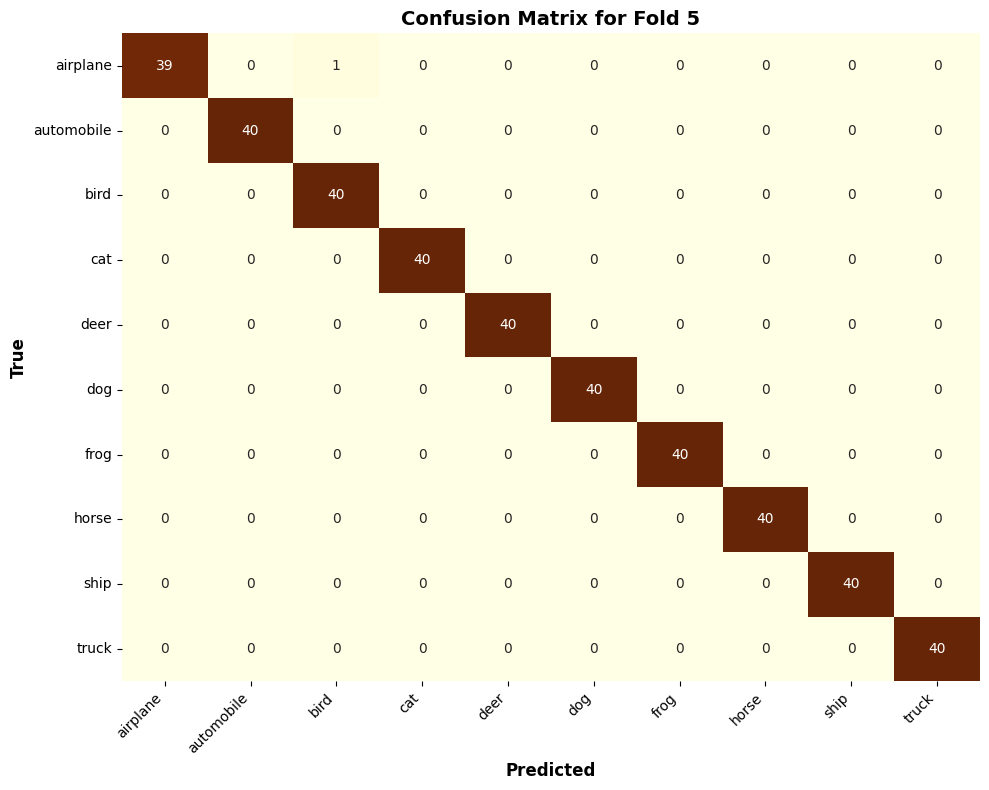


=== Final Results (5-Fold CV) ===
Average Accuracy: 0.9750 ± 0.0426
Average F1-Score: 0.9748 ± 0.0430


In [ ]:
# Load pretrained RepVGG-A2
model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_repvgg_a2", pretrained=True, trust_repo=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

# Freeze early layers
for name, param in model.named_parameters():
    if "stage1" in name or "stage2" in name:
        param.requires_grad = False

# Replace classifier
model.linear = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.linear.in_features, 10)
).to(device)

# Define loss function with class weights
class_weights = torch.tensor([1.0, 1.0, 1.0, 1.2, 1.0, 1.2, 1.0, 1.0, 1.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Define 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=789)
folds = list(skf.split(data, labels))

# Store results
accuracies = []
f1_scores = []
confusion_matrices = []  # Store confusion matrices for each fold


for fold, (train_idx, test_idx) in enumerate(folds):
    print(f"\n=== Training Fold {fold+1}/5 ===")

    # Analyze class distribution for every fold
    print(f"Fold {fold+1} test class distribution:")
    class_counts = np.bincount(labels[test_idx])
    for i, count in enumerate(class_counts):
        print(f"  {class_names[i]} (Class {i}): {count} samples")

    # Create datasets
    train_dataset = CIFAR10_1_Dataset(
        torch.tensor(data[train_idx], dtype=torch.float32),
        torch.tensor(labels[train_idx], dtype=torch.long),
        transform=train_transform
    )
    test_dataset = CIFAR10_1_Dataset(
        torch.tensor(data[test_idx], dtype=torch.float32),
        torch.tensor(labels[test_idx], dtype=torch.long),
        transform=test_transform
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    # Optimizer and scheduler
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=4e-5, weight_decay=5e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    # Training loop
    best_val_loss = float('inf')
    patience = 7
    counter = 0
    model.train()
    for epoch in range(50):
        running_loss = 0.0
        correct = 0
        total = 0
        # Unfreeze stage2 at epoch 6
        if epoch == 6:
            for name, param in model.named_parameters():
                if "stage2" in name:
                    param.requires_grad = True
            optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=5e-2)

        for i, (images, targets) in enumerate(train_loader):
            images, targets = images.to(device), targets.to(device)

            # Apply MixUp
            if np.random.rand() < 0.2:
                images, targets_a, targets_b, lam = mixup_data(images, targets, alpha=0.2, device=device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            else:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

            if (i + 1) % 50 == 0:
                print(f"Fold {fold+1}, Epoch {epoch+1}, Batch {i+1}/{len(train_loader)}, "
                      f"Batch Loss: {loss.item():.4f}")

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        print(f"Fold {fold+1}, Epoch {epoch+1}, Average Loss: {epoch_loss:.4f}, "
              f"Training Accuracy: {epoch_acc:.4f}")

        # Validation with TTA
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for images, targets in test_loader:
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, targets).item()
                outputs = apply_tta(model, images, device)
                _, tta_preds = torch.max(outputs, 1)
                val_correct += (tta_preds == targets).sum().item()
                val_total += targets.size(0)
                all_preds.extend(tta_preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
        val_loss /= len(test_loader)
        val_acc = val_correct / val_total
        print(f"Fold {fold+1}, Epoch {epoch+1}, Validation Loss: {val_loss:.4f}, "
              f"Validation Accuracy (TTA): {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f'repvgg_a2_fold_{fold+1}.pth')
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at Epoch {epoch+1}")
                break
        model.train()
        scheduler.step()

    # Final evaluation
    model.load_state_dict(torch.load(f'repvgg_a2_fold_{fold+1}.pth'))
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = apply_tta(model, images, device)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')
    accuracies.append(acc)
    f1_scores.append(f1)
    print(f"Fold {fold+1} - Final Validation Accuracy (TTA): {acc:.4f}, Validation F1-Score: {f1:.4f}")
    print(f"Fold {fold+1} Classification Report:")
    print(classification_report(all_targets, all_preds, digits=4))

    # Compute and store confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    confusion_matrices.append(cm)

    # Plot and save per-fold confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted', fontsize=12, weight='bold')
    plt.ylabel('True', fontsize=12, weight='bold')
    plt.title(f'Confusion Matrix for Fold {fold+1}', fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_fold_{fold+1}.png')
    plt.show()
    plt.close()

# Report final results
print(f"\n=== Final Results (5-Fold CV) ===")
print(f"Average Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

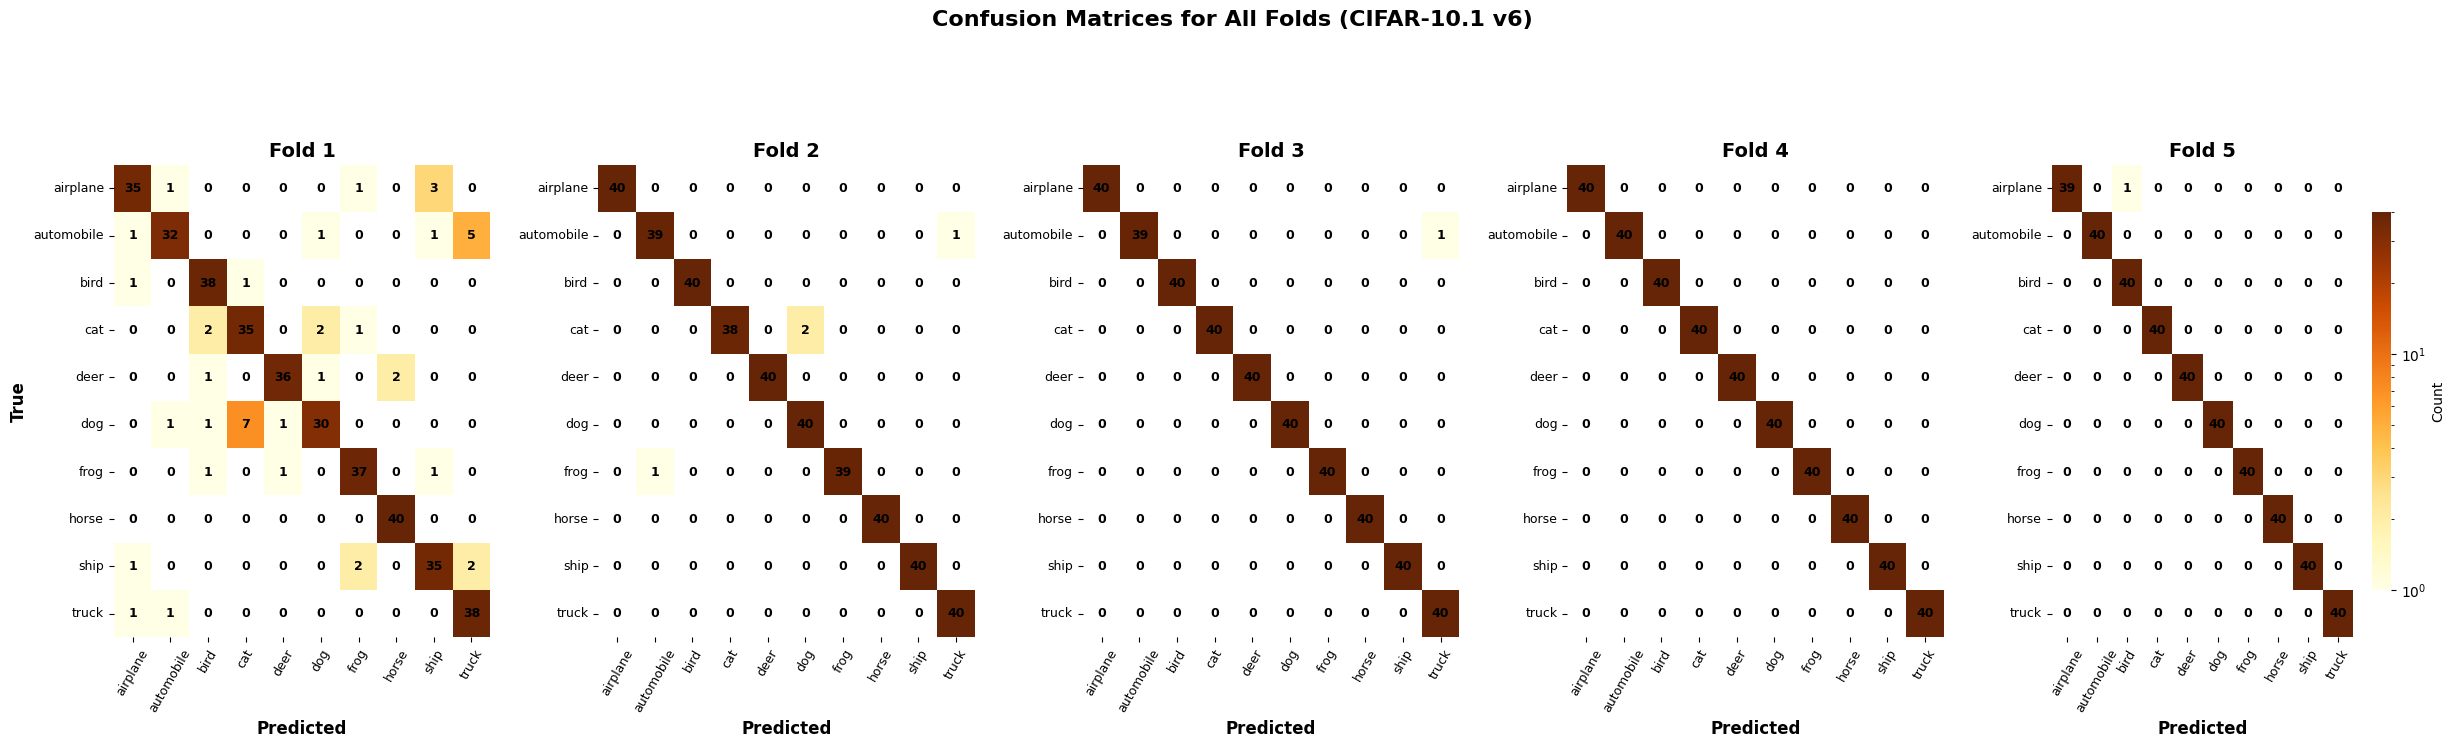

In [ ]:

plt.figure(figsize=(25, 7))

# Plot confusion matrices
for fold in range(5):
    plt.subplot(1, 5, fold + 1)
    # Use a logarithmic normalization to better spread the colors
    sns.heatmap(confusion_matrices[fold],
                annot=True,
                fmt='d',
                cmap='YlOrBr',  # Changed to a more contrasting colormap
                norm=plt.cm.colors.LogNorm(vmin=1, vmax=40),  # Log scale, starting at 1 to avoid log(0)
                xticklabels=class_names,
                yticklabels=class_names,
                cbar=True if fold == 4 else False,
                cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={"size": 9, "color": "black", "weight": "bold"})
    plt.xlabel('Predicted', fontsize=12, weight='bold')
    plt.ylabel('True' if fold == 0 else '', fontsize=12, weight='bold')
    plt.title(f'Fold {fold+1}', fontsize=14, weight='bold')
    plt.xticks(rotation=60, ha='center', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

plt.suptitle('Confusion Matrices for All Folds (CIFAR-10.1 v6)', fontsize=16, weight='bold', y=1.08)
plt.tight_layout(pad=2)

# Save and display
plt.savefig('all_folds_confusion_matrices_improved.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

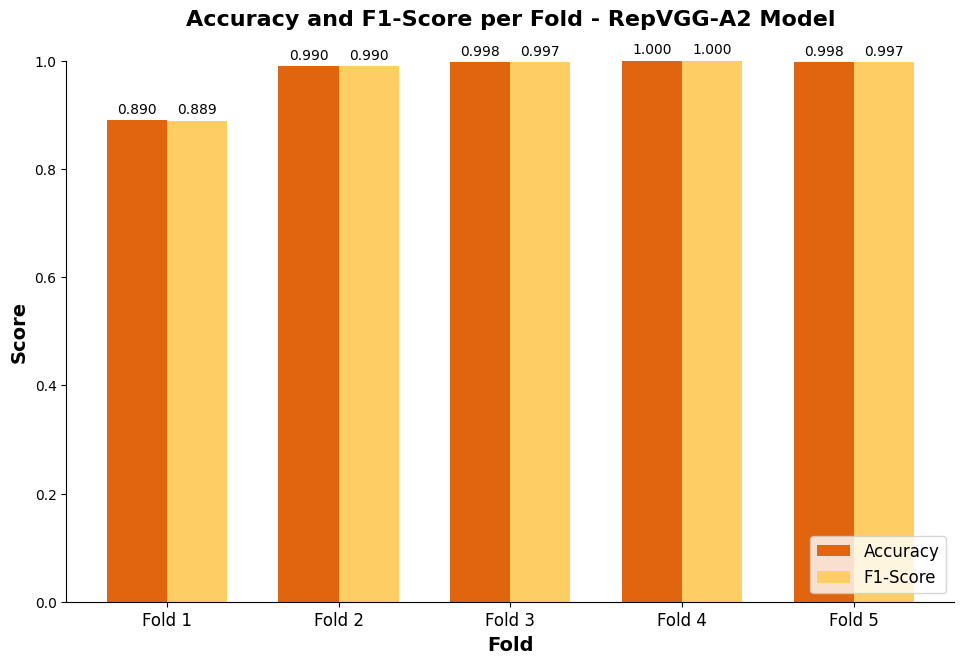

In [ ]:
# Create figure with increased height
plt.figure(figsize=(10, 7))

# Define data
x = np.arange(5)
width = 0.35

# Plot bars with muted palette
palette = sns.color_palette("YlOrBr", 2)
bar1 = plt.bar(x - width/2, accuracies, width, label='Accuracy', color=palette[1])
bar2 = plt.bar(x + width/2, f1_scores, width, label='F1-Score', color=palette[0])

# Add value labels on bars
for bar in [bar1, bar2]:
    plt.bar_label(bar, fmt='%.3f', fontsize=10, padding=3, color='black')

# Customize plot
plt.xlabel('Fold', fontsize=14, weight='bold')
plt.ylabel('Score', fontsize=14, weight='bold')
plt.title('Accuracy and F1-Score per Fold - RepVGG-A2 Model', fontsize=16, weight='bold', y=1.05)
plt.xticks(x, [f'Fold {i+1}' for i in range(5)], fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12, loc='lower right')

# Adjust layout with padding and remove top/right spines
plt.tight_layout(pad=2)
sns.despine()

# Save and display
plt.savefig('fold_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()